In [21]:
import numpy as np
import matplotlib.pyplot as plt
import kcorrect
from astropy.table import Table
import pandas as pd
from scipy.interpolate import interp1d
from astropy.cosmology import FlatLambdaCDM
#from dustmaps.sfd import SFDQuery

In [2]:
#kcorrect?

In [3]:
#import healpy

In [4]:
from dustmaps.config import config
config.reset()

In [5]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [6]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Custom bandpasses

## F140W (JH gap) reprocess

In [7]:
F140W_rep = False

if F140W_rep == True:
    
    # Read bandpass
    bp_F140W = np.loadtxt('/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/HST_images/wfcam_JH.dat')
    wav_F140W = np.round(bp_F140W[:,0],1)
    resp_F140W = bp_F140W[:,1]    
    
    # Make table
    t = Table([wav_F140W,resp_F140W],
               names=('lambda', 'pass'))
    
    # Save in fixed width format
    t.write('/opt/anaconda3/lib/python3.9/site-packages/kcorrect/data/responses/wfcam_JH.dat', 
            format='ascii.fixed_width', overwrite=True) 

## MUSE write

In [8]:
wav0_MUSE = 4751.284541786687 # In Å
dwav_MUSE = 1.25
N_pix_MUSE = 3681

wav_MUSE = np.arange(wav0_MUSE, wav0_MUSE+N_pix_MUSE*dwav_MUSE, dwav_MUSE)

In [9]:
# Define this for automation later
bandpasses_MUSE = {'pseudo_g': [4800,5800], 'pseudo_r': [6000,7500], 'pseudo_i': [7500,9000]}

In [10]:
MUSE_write = False

if MUSE_write == True:
    for k in list(bandpasses_MUSE.keys()):

        # Get wavelength limits
        wav_lims = bandpasses_MUSE[k]

        # Read in MUSE response
        df = pd.read_csv('/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/MUSE/MUSE_bp.csv')
        df.columns = ['lambda','pass']
        # Edge effects
        wav_arr = 10*np.array([485,490] + list(df['lambda']) + [900,905]) # To Å
        pass_arr = np.array([0,29.808658] + list(df['pass']) + [25.065098,0])/100 # To fraction

        # Fix negatives
        pass_arr[pass_arr<=0] = 0
        
        # Interpolate along uniform wavelength array
        pass_interp = interp1d(wav_arr, pass_arr, fill_value=0, bounds_error=False)(wav_MUSE)

        # Isolate relevant wavelengths
        wav_idx = (wav_MUSE<wav_lims[0])|(wav_MUSE>wav_lims[1])
        # Create bandpass
        pass_interp[wav_idx] = 0 # Set bandpass not in filter


        # Save bandpass
        # Make table
        wav_idx_save = (wav_MUSE>=wav_lims[0]-15*dwav_MUSE)&(wav_MUSE<=wav_lims[1]+15*dwav_MUSE)
        t = Table([wav_MUSE[wav_idx_save],pass_interp[wav_idx_save]],
                   names=('lambda', 'pass'))

        plt.plot(wav_MUSE[wav_idx_save], pass_interp[wav_idx_save])

        # Save in fixed width format
        t.write('/opt/anaconda3/lib/python3.9/site-packages/kcorrect/data/responses/muse_{}.dat'.format(k), 
                format='ascii.fixed_width', overwrite=True) 

# Utilities

Some definitions for HST

In [11]:
# Calibration and pivot wavelength for F814W
PHOTPLAM_F814W = 8045.5352
PHOTFLAM_F814W = 7.092805575e-20
# F_nu sensitivity calculation using pivot wavelength and F_lam sensitivity
# Formula presumably converts F_lam in erg/s/Å to F_nu in Jy
PHOTFNU_814W = 3.34e+4*PHOTPLAM_F814W**2*PHOTFLAM_F814W
t_exp_F814W = 546.0

# Calibration for F140W
PHOTFNU_F140W = 9.5432426E-08
t_exp_F140W = 555.875916

# Calibration for F160W 
PHOTFNU_F160W = 1.5308434e-07
t_exp_F160W = 227.93692 # seconds


# Make global dictionaries
PHOTFNU_dict = {'F814W':PHOTFNU_814W, 'F140W':PHOTFNU_F140W, 'F160W':PHOTFNU_F160W}
t_exp_dict = {'F814W':t_exp_F814W, 'F140W':t_exp_F140W, 'F160W':t_exp_F160W}

In [12]:
# Magnitude -> Janskys -> e/s -> e -> sqrt(e) -> err/s -> d(Jansky) -> dm = -(2.5/ln(10))*d(Jansky)/Jansky

Function to compute HST photometric error

In [13]:
def compute_phot_err(mags):
    
    '''
    mags: list of AB magnitudes in order of increasing wavelength
    '''
    
    F_nu_Jy_arr = 3631*10**(-0.4*mags) # In Jy
    
    dmags = np.zeros(len(mags))

    for i in range(len(PHOTFNU_dict)):
        
        filt = list(PHOTFNU_dict.keys())[i]
        F_nu_Jy = F_nu_Jy_arr[i]

        count_rate = F_nu_Jy/PHOTFNU_dict[filt] # Divide by sensitivity
        counts = count_rate*t_exp_dict[filt] # Get counts

        counts_err = np.sqrt(counts) # Get count error assuming Poisson counting
        count_rate_err = counts_err/t_exp_dict[filt] # Divide counts by exposure time
        dF_nu_Jy = count_rate_err*PHOTFNU_dict[filt] # Get error in F_nu

        # Compute error in magnitude using propagation of error
        dmags[i] = np.abs((-2.5/np.log(10))*(dF_nu_Jy/F_nu_Jy))    
    
    return np.round(dmags,3)

All bandpasses

In [14]:
wavs_pass_min = np.array([4800,6000,7500,6800,11370,14210])
wavs_pass_max = np.array([5800,7500,9000,10000,16450,19240])

wavs_pass_cen = .5*(wavs_pass_max+wavs_pass_min)
dwavs_pass = .5*(wavs_pass_max-wavs_pass_min)

Extinction scaled to E(B-V)=1

In [15]:
ext_scale = np.array([3.255, 2.446, 1.758, 1.743, 0.754, 0.556])

Functions for maggies and ivar

In [16]:
def get_maggies(m):
    # Maggies
    mu = 10**(-0.4*m)
    return mu

In [17]:
def get_ivar_maggies(mu, dm):
    dmu = np.abs(-0.4*np.log(10)*dm*mu)
    # Inverse variance for maggies
    return dmu**-2

Functions for Mstar

In [18]:
def get_Mstar_15(Mr, Mg):
    
    if Mg-Mr<0.15:
        ML = -0.6
    else:
        ML = -1.01 + 2.95*(Mg-Mr) - 1.67*(Mg-Mr)**2
    
    return 1.872 - 0.4*Mr + ML

In [19]:
def get_Mstar_24(MB, ug):
    
    if ug<0.9:
        return -0.36*MB + 2.17*ug + 1.1
    else:
        return -0.36*MB + 0.72*ug + 2.4

## z=0.0966

In [20]:
redshift = 0.0966
ebv = 0.0397

In [21]:
MUSE_mags = np.array([24.653, 24.175, 24.145])
dMUSE_mags = np.array([0.003, 0.002, 0.004])

HST_mags = np.array([23.803,22.883,22.655])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [22]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [23]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g


In [24]:
responses_out = ['sdss_r0', 'sdss_g0',]
responses_map = ['muse_pseudo_r', 'muse_pseudo_g']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

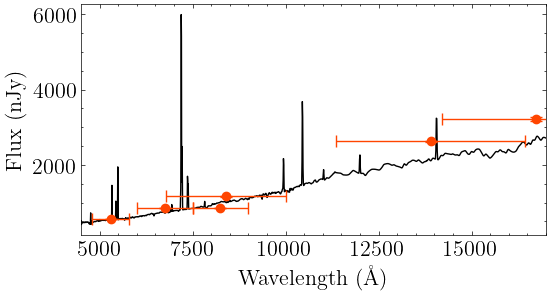

In [25]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [26]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [27]:
np.round(Mstar_KC,1)

7.4

In [28]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [29]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-14.08, -13.55, 7.6)

### Q24

In [30]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [31]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_g
muse_pseudo_g
muse_pseudo_g


In [32]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_g', 'muse_pseudo_g', 'muse_pseudo_g']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

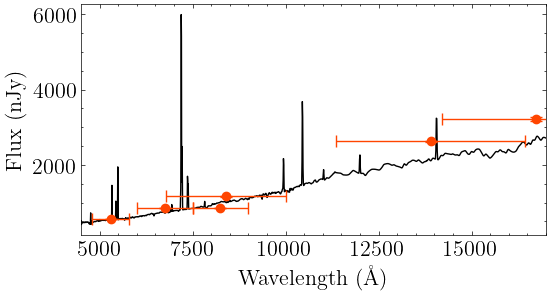

In [33]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [34]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [35]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-13.43, 0.72, 7.5)

## z=0.1203

In [36]:
redshift = 0.1203
ebv = 0.0397

In [37]:
MUSE_mags = np.array([18.85872, 18.12838, 17.69731])
dMUSE_mags = np.array([1e-5, 1e-5, 1e-5])

HST_mags = np.array([18.03,16.898,16.789])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [38]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [39]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g


In [40]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

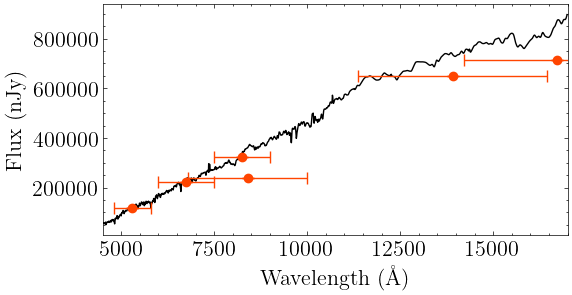

In [41]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [42]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [43]:
np.round(Mstar_KC,1)

10.4

In [44]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [45]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-20.65, -19.81, 10.4)

### Q24

In [46]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [47]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_g
muse_pseudo_g
muse_pseudo_g


In [48]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_g', 'muse_pseudo_g', 'muse_pseudo_g']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

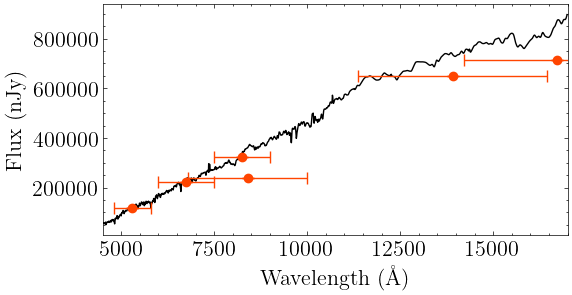

In [49]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [50]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [51]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-19.47, 1.75, 10.7)

## z=0.1204

In [52]:
redshift = 0.1204
ebv = 0.0397

In [53]:
MUSE_mags = np.array([20.06678, 19.5231, 19.20591])
dMUSE_mags = np.array([4e-05, 2e-05, 4e-05])

HST_mags = np.array([19.784,18.48,18.369])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [54]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [55]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g


In [56]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

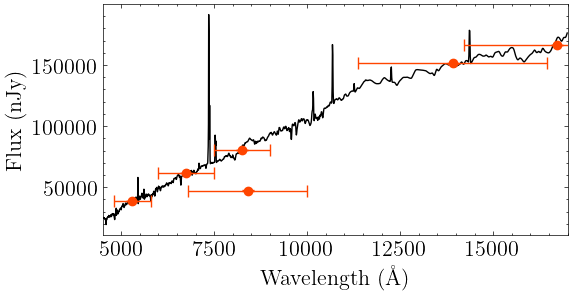

In [57]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [58]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [59]:
np.round(Mstar_KC,1)

9.7

In [60]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [61]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-19.25, -18.62, 9.8)

### Q24

In [62]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [63]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_g
muse_pseudo_g
muse_pseudo_g


In [64]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_g', 'muse_pseudo_g', 'muse_pseudo_g']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

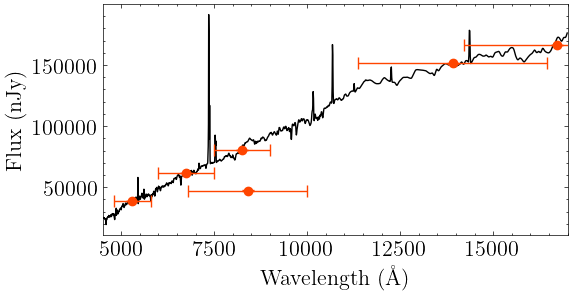

In [65]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [66]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [67]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-18.39, 1.35, 10.0)

## z=0.1264

In [68]:
redshift = 0.1264
ebv = 0.0397

In [69]:
MUSE_mags = np.array([26.74,26.29,25.46])
dMUSE_mags = np.array([0.02, 0.01, 0.02])

HST_mags = np.array([25.431,23.78,23.555])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [70]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [71]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g


In [72]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

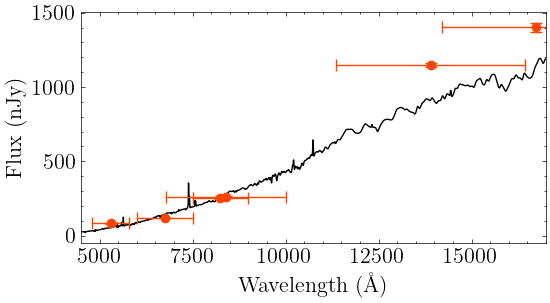

In [73]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [74]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [75]:
np.round(Mstar_KC,1)

7.3

In [76]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [77]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-12.66, -12.08, 7.1)

### Q24

In [78]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [79]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_g
muse_pseudo_g
muse_pseudo_g


In [80]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_g', 'muse_pseudo_g', 'muse_pseudo_g']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

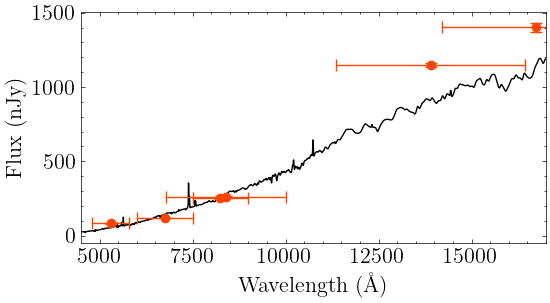

In [81]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [82]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [83]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-11.71, 1.68, 7.8)

## z=0.1335

In [84]:
redshift = 0.1335
ebv = 0.0404

In [86]:
MUSE_mags = np.array([28.7,27.8,26.74])
dMUSE_mags = np.array([0.1, 0.05, 0.05])

HST_mags = np.array([26.456, 24.939, 24.807])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [87]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [88]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g


In [89]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

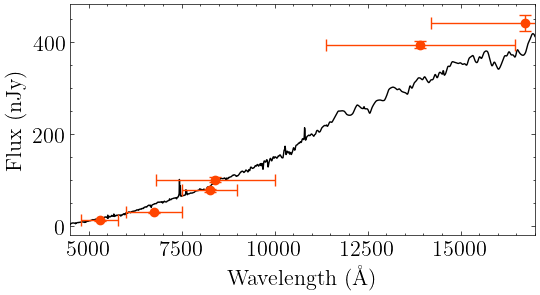

In [90]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [91]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [92]:
np.round(Mstar_KC,1)

6.9

In [93]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [94]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-11.3, -10.28, 6.7)

### Q24

In [95]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [96]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_g
muse_pseudo_g
muse_pseudo_g


In [97]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_g', 'muse_pseudo_g', 'muse_pseudo_g']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

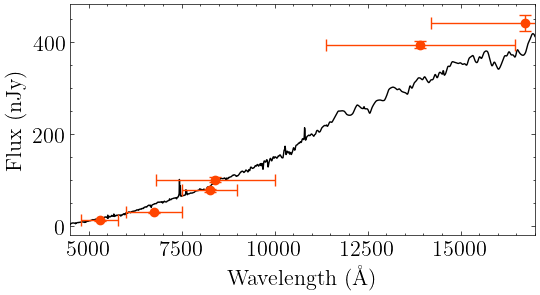

In [98]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [99]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [100]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-9.85, 2.36, 7.6)

## z=0.1393

In [101]:
redshift = 0.1393
ebv = 0.0397

In [102]:
MUSE_mags = np.array([24.134, 23.889, 23.58])
dMUSE_mags = np.array([0.003, 0.003, 0.005])

HST_mags = np.array([23.797,22.784,22.655])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [103]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [104]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g


In [105]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

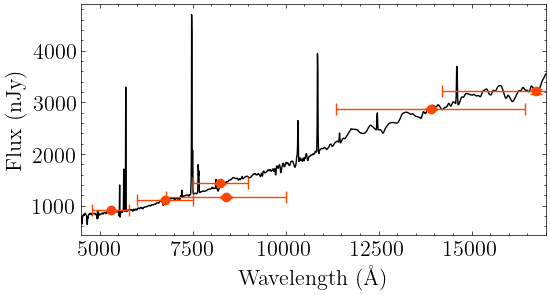

In [106]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [107]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [108]:
np.round(Mstar_KC,1)

7.9

In [109]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [110]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-15.23, -14.93, 7.7)

### Q24

In [111]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [112]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_g
muse_pseudo_g
muse_pseudo_g


In [113]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_g', 'muse_pseudo_g', 'muse_pseudo_g']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

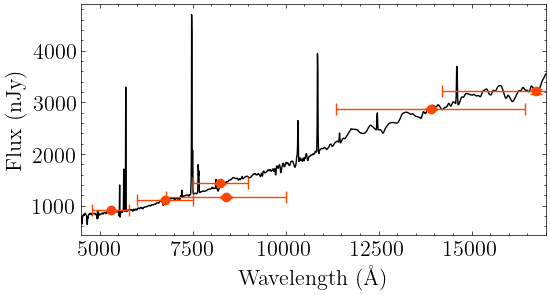

In [114]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [115]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [116]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-14.86, 0.45, 7.4)

## z=0.2791

In [117]:
redshift = 0.2791
ebv = 0.0404

In [133]:
MUSE_mags = np.array([25.698, 25.247, 25.11])
dMUSE_mags = np.array([0.006, 0.004, 0.01])

HST_mags = np.array([25.358, 23.432, 23.282])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [134]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [135]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfpc2_f814w
muse_pseudo_r


In [136]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfpc2_f814w', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

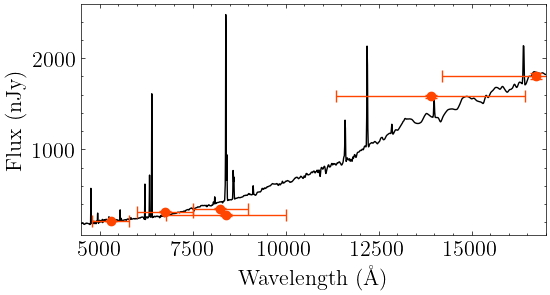

In [137]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [138]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [139]:
np.round(Mstar_KC,1)

8.3

In [140]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [141]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-15.25, -15.21, 7.4)

### Q24

In [142]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [143]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_g
muse_pseudo_g
muse_pseudo_r


In [144]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_g', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

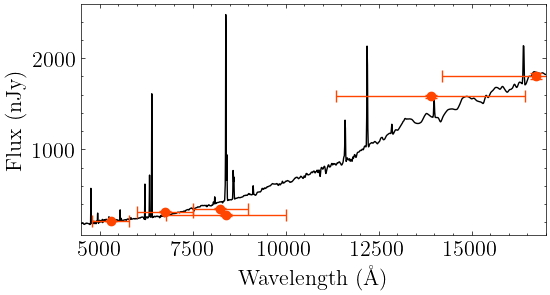

In [145]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [146]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [147]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-15.0, 0.41, 7.4)

## z=0.2915

In [164]:
redshift = 0.2915
ebv = 0.0404

In [165]:
MUSE_mags = np.array([26.49, 26.15, 25.5])
dMUSE_mags = np.array([0.01, 0.01, 0.01])

HST_mags = np.array([25.617, 23.838, 23.676])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [166]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [167]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfpc2_f814w
muse_pseudo_r


In [168]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfpc2_f814w', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

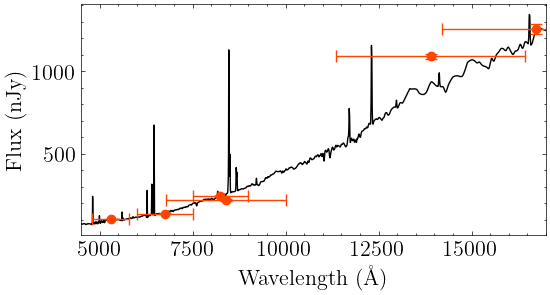

In [169]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [170]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [171]:
np.round(Mstar_KC,1)

8.2

In [172]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [173]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-15.11, -14.33, 8.2)

### Q24

In [174]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [175]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_g
muse_pseudo_g
muse_pseudo_r


In [176]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_g', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

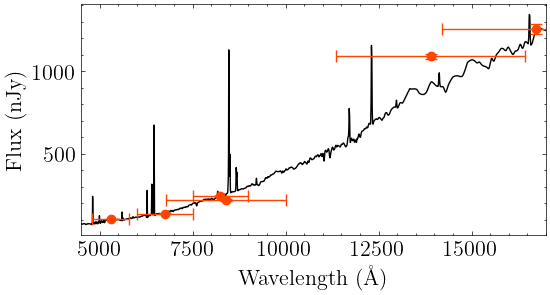

In [177]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [178]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [179]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-14.37, 0.31, 6.9)

## z=0.3198

In [180]:
redshift = 0.3198
ebv = 0.0404

In [181]:
MUSE_mags = np.array([24.01, 23.434, 23.126])
dMUSE_mags = np.array([0.001, 0.001, 0.002])

HST_mags = np.array([23.027,21.89,21.746])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [182]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [183]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r


In [184]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

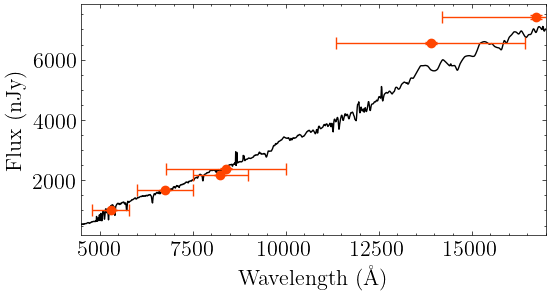

In [185]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [186]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [187]:
np.round(Mstar_KC,1)

9.1

In [188]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [189]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-17.75, -17.32, 8.9)

### Q24

In [190]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [191]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_g
muse_pseudo_g
muse_pseudo_r


In [192]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_g', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

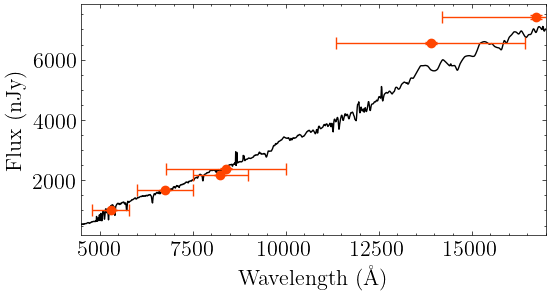

In [193]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [194]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [195]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-17.16, 0.94, 9.3)

## z=0.3286

In [196]:
redshift = 0.3286
ebv = 0.0404

In [197]:
MUSE_mags = np.array([22.2104, 21.0403, 20.4848])
dMUSE_mags = np.array([0.0003, 0.0001, 0.0002])

HST_mags = np.array([20.638, 19.609, 19.494])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [198]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [199]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r


In [200]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

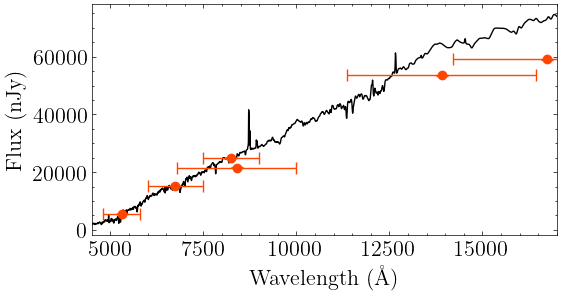

In [201]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [202]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [203]:
np.round(Mstar_KC,1)

10.3

In [204]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [205]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-20.47, -19.66, 10.3)

### Q24

In [206]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [207]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_g
muse_pseudo_g
muse_pseudo_r


In [208]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_g', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

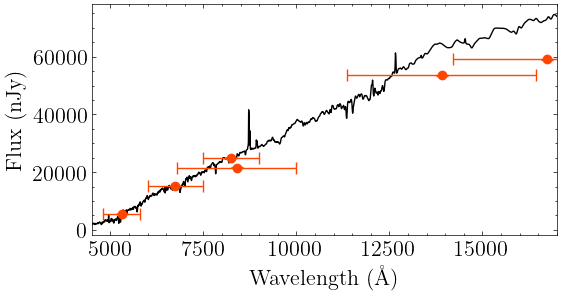

In [209]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [210]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [211]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-19.35, 1.67, 10.6)

## z=0.3752

In [212]:
redshift = 0.3752
ebv = 0.0404

In [213]:
MUSE_mags = np.array([24.899, 24.147, 23.981])
dMUSE_mags = np.array([0.003, 0.002, 0.003])

HST_mags = np.array([24.418, 22.834, 22.624])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [214]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [215]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r


In [216]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

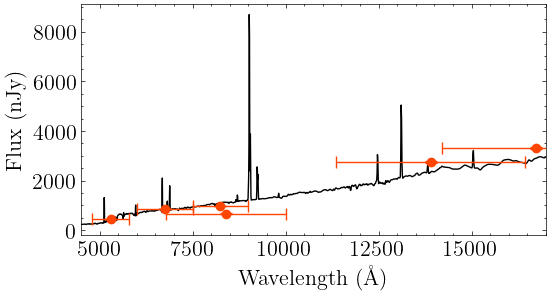

In [217]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [218]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [219]:
np.round(Mstar_KC,1)

8.8

In [220]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [221]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-17.44, -17.05, 8.7)

### Q24

In [222]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [223]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
muse_pseudo_r


In [224]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

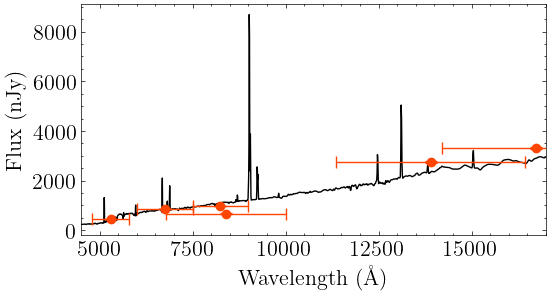

In [225]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [226]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [227]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-16.91, 1.11, 9.3)

## z=0.3759

In [228]:
redshift = 0.3759
ebv = 0.0397

In [229]:
MUSE_mags = np.array([26.92, 25.776, 25.46])
dMUSE_mags = np.array([0.02, 0.008, 0.02])

HST_mags = np.array([25.077,23.472,23.441])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [230]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [231]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r


In [232]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

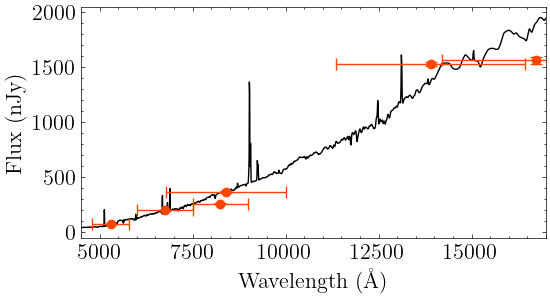

In [233]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [234]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [235]:
np.round(Mstar_KC,1)

8.6

In [236]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [237]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-15.96, -15.36, 8.4)

### Q24

In [238]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [239]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
muse_pseudo_r


In [240]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

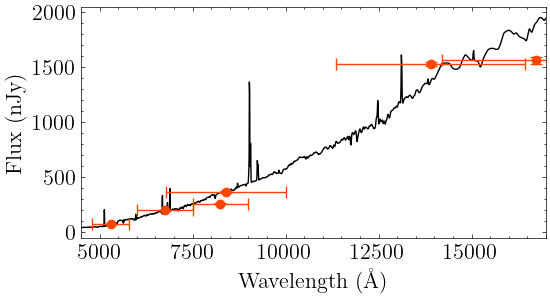

In [241]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [242]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [243]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-15.08, 1.44, 8.9)

## z=0.4395

In [244]:
redshift = 0.4395
ebv = 0.0404

In [245]:
MUSE_mags = np.array([25.477, 24.215, 23.703])
dMUSE_mags = np.array([0.006, 0.002, 0.003])

HST_mags = np.array([23.55, 22.146, 22.313])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [246]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [247]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r


In [248]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

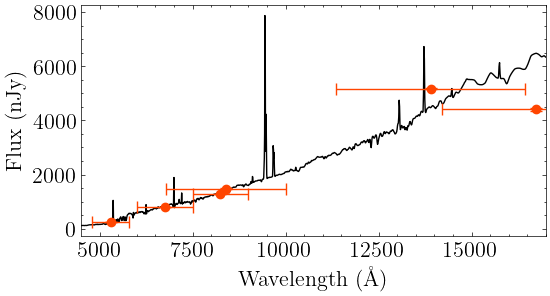

In [249]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [250]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [251]:
np.round(Mstar_KC,1)

9.3

In [252]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [253]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-18.2, -17.41, 9.4)

### Q24

In [254]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [255]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
muse_pseudo_r


In [256]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

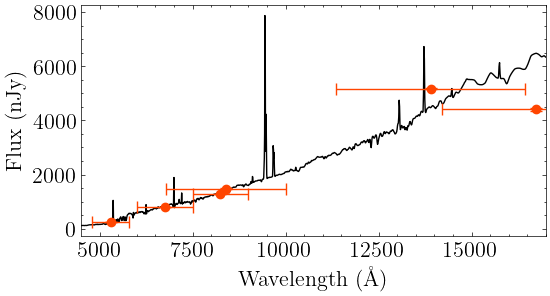

In [257]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [258]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [259]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-17.18, 1.49, 9.7)

## z=0.4581

In [260]:
redshift = 0.4581
ebv = 0.0404

In [261]:
MUSE_mags = np.array([23.1248, 22.4526, 22.3413])
dMUSE_mags = np.array([0.0006, 0.0004, 0.0008])

HST_mags = np.array([22.217,21.346,21.363])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [262]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [263]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r


In [264]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

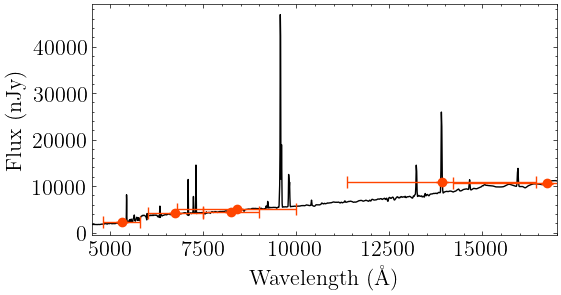

In [265]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [266]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [267]:
np.round(Mstar_KC,1)

9.5

In [268]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [269]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-19.61, -19.27, 9.5)

### Q24

In [270]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [271]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
muse_pseudo_r


In [272]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

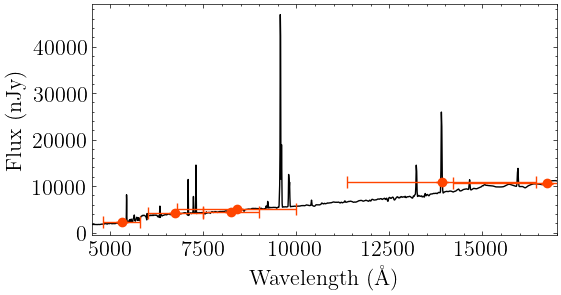

In [273]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [274]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [275]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-19.16, 0.72, 9.6)

## z=0.4784

In [276]:
redshift = 0.4784
ebv = 0.0397

In [277]:
MUSE_mags = np.array([23.957, 23.166, 22.579])
dMUSE_mags = np.array([0.003, 0.001, 0.002])

HST_mags = np.array([23.194,21.987,21.776])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [278]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [279]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r


In [280]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

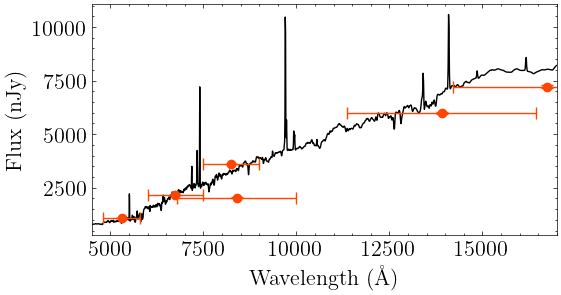

In [281]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [282]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [283]:
np.round(Mstar_KC,1)

9.8

In [284]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [285]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-19.45, -18.71, 9.9)

### Q24

In [286]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [287]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
muse_pseudo_r


In [288]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

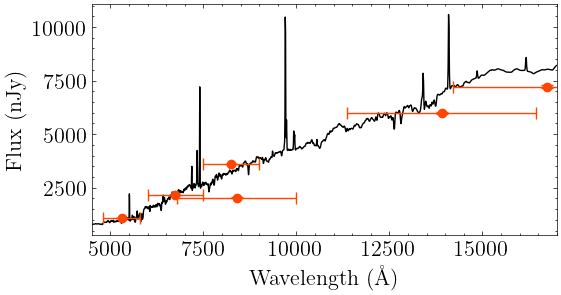

In [289]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [290]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [291]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-18.49, 0.83, 9.6)

## z=0.5191

In [293]:
redshift = 0.5191
ebv = 0.0404

In [294]:
MUSE_mags = np.array([25.3, 23.807, 23.279])
dMUSE_mags = np.array([0.004, 0.001, 0.002])

HST_mags = np.array([23.149,21.69,21.535])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [295]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [296]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r


In [297]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

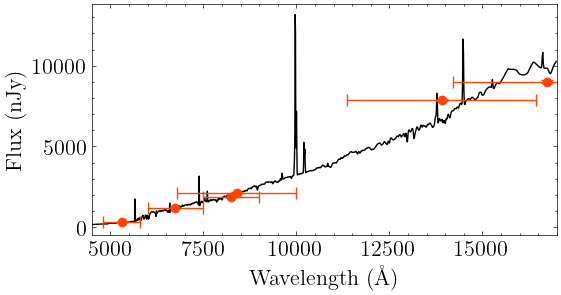

In [298]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [299]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [300]:
np.round(Mstar_KC,1)

9.7

In [301]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [302]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-19.16, -18.36, 9.8)

### Q24

In [303]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [304]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
muse_pseudo_r


In [305]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

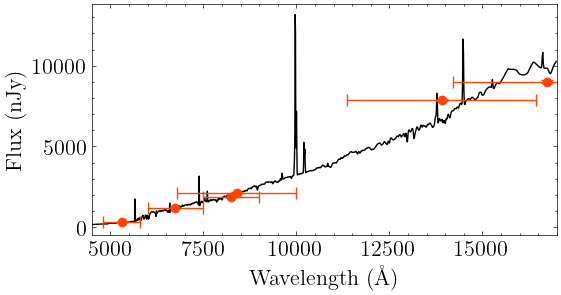

In [306]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [307]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [308]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-18.12, 1.52, 10.0)

## z=0.5205

In [309]:
redshift = 0.5205
ebv = 0.0404

In [310]:
MUSE_mags = np.array([23.893, 22.791, 22.334])
dMUSE_mags = np.array([0.001, 0.001, 0.001])

HST_mags = np.array([22.342,21.384,21.272])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [311]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [312]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r


In [313]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

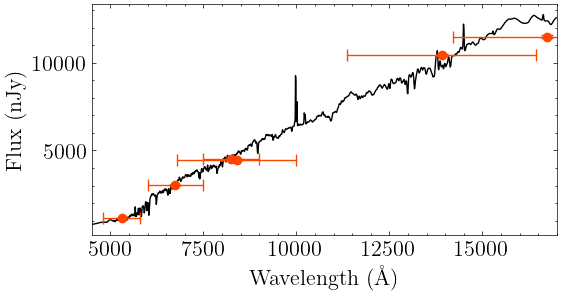

In [314]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [315]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [316]:
np.round(Mstar_KC,1)

10.0

In [317]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [318]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-19.93, -19.35, 10.0)

### Q24

In [319]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [320]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
muse_pseudo_r


In [321]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

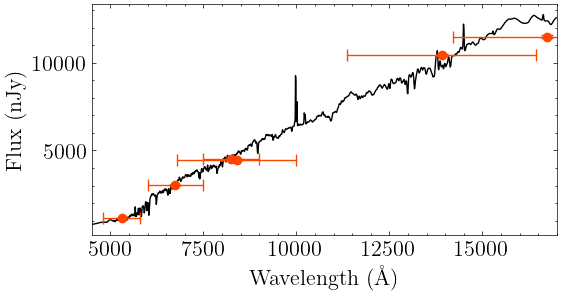

In [322]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [323]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [325]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-19.15, 1.14, 10.1)

## z=0.5257

In [326]:
redshift = 0.5257
ebv = 0.0397

In [327]:
MUSE_mags = np.array([27.99, 27.16, 26.57])
dMUSE_mags = np.array([0.07, 0.04, 0.06])

HST_mags = np.array([26.789, 24.939, 24.801])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [346]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [347]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r


In [348]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

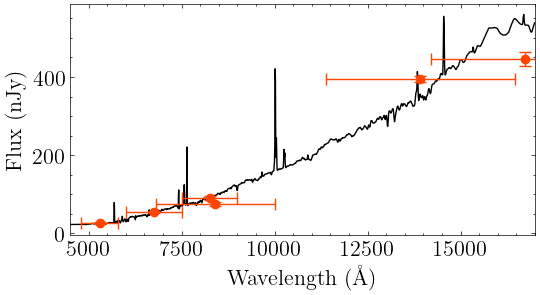

In [349]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [350]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [351]:
np.round(Mstar_KC,1)

8.5

In [352]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [353]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-15.89, -15.08, 8.5)

### Q24

In [354]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [355]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
muse_pseudo_r


In [356]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

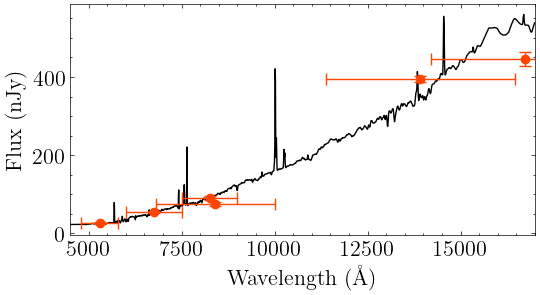

In [357]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [358]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [359]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-14.83, 0.96, 8.4)

## z=0.5356

In [360]:
redshift = 0.5356
ebv = 0.0404

In [361]:
MUSE_mags = np.array([22.9101, 21.6208, 21.0552])
dMUSE_mags = np.array([0.0005, 0.0002, 0.0002])

HST_mags = np.array([21.132, 20.225, 20.069])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [362]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [363]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r


In [364]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

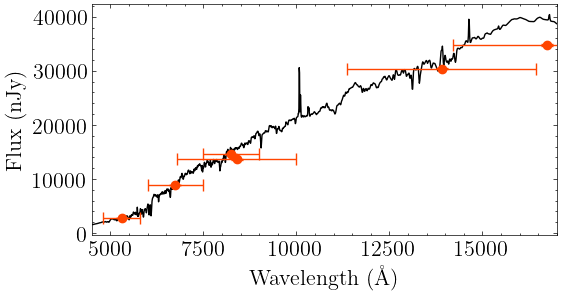

In [365]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [366]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [367]:
np.round(Mstar_KC,1)

10.6

In [368]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [369]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-21.3, -20.66, 10.6)

### Q24

In [370]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [371]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
muse_pseudo_r


In [372]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'muse_pseudo_r']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

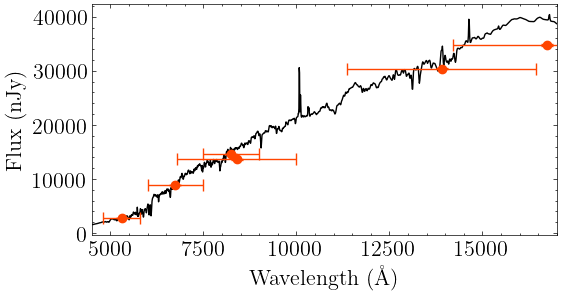

In [373]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [374]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [375]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-20.41, 1.37, 10.7)

## z=0.5723

In [376]:
redshift = 0.5723
ebv = 0.0397

In [377]:
MUSE_mags = np.array([23.858, 22.26, 21.5364])
dMUSE_mags = np.array([0.001, 0.0003, 0.0004])

HST_mags = np.array([21.719, 20.567, 20.415])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [378]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [379]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w


In [380]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

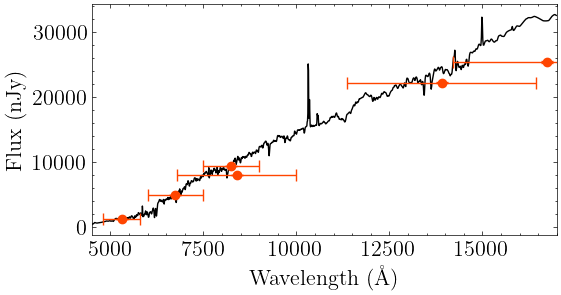

In [381]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [382]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [383]:
np.round(Mstar_KC,1)

10.6

In [384]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [385]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-21.08, -20.22, 10.6)

### Q24

In [386]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [387]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
wfpc2_f814w


In [388]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

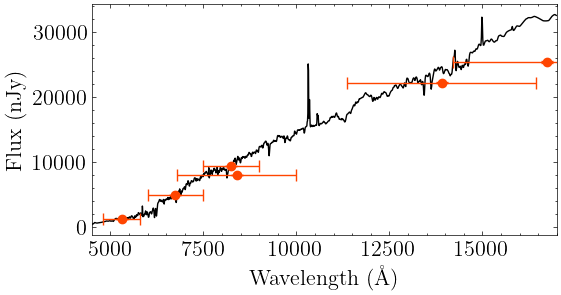

In [389]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [390]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [391]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-20.04, 1.58, 10.8)

## z=0.6164

In [392]:
redshift = 0.6164
ebv = 0.0394

In [393]:
HST_mags = np.array([23.3,22.469,22.305])
dHST_mags = compute_phot_err(HST_mags)

mags = HST_mags
dmags = dHST_mags

mags -= ebv*ext_scale[3:]

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [394]:
responses_lams = np.array([8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [395]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfpc2_f814w
wfpc2_f814w


In [396]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfpc2_f814w', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

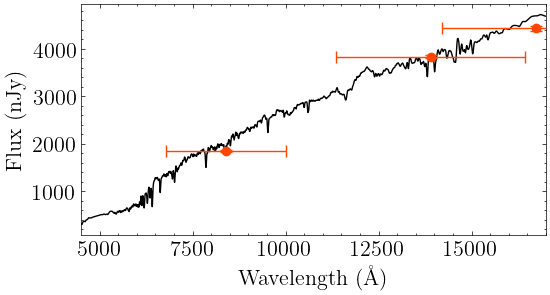

In [397]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen[3:], 1e9*3631*maggies, 
            xerr=dwavs_pass[3:], yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [398]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [399]:
np.round(Mstar_KC,1)

9.8

In [400]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [401]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-19.45, -18.95, 9.7)

### Q24

In [402]:
responses_lams = np.array([8140,14000,16000])
responses_out_lams = np.array([[4500,3543,4770]])

In [403]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfpc2_f814w
wfpc2_f814w
wfpc2_f814w


In [404]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['wfpc2_f814w', 'wfpc2_f814w', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

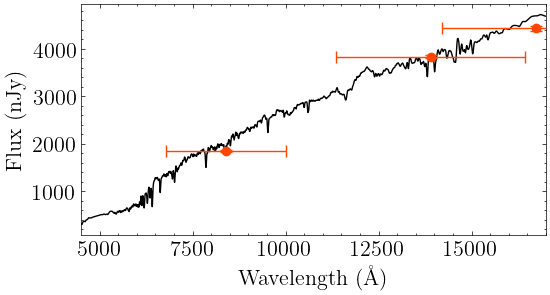

In [405]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen[3:], 1e9*3631*maggies, 
            xerr=dwavs_pass[3:], yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [406]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [407]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-18.78, 1.04, 9.9)

## z=0.6174

In [408]:
redshift = 0.6174
ebv = 0.0404

In [409]:
MUSE_mags = np.array([26.51, 25.625, 25.15])
dMUSE_mags = np.array([0.01,  0.007, 0.01])

HST_mags = np.array([25.294, 23.433, 23.254])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [410]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [411]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w


In [412]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

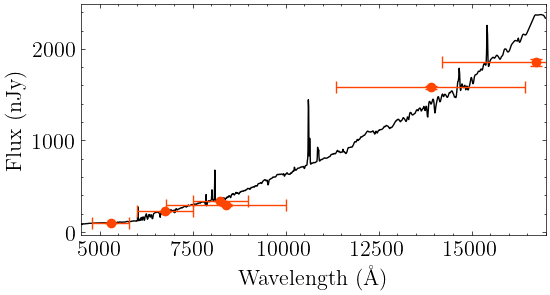

In [413]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [414]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [415]:
np.round(Mstar_KC,1)

9.3

In [416]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [417]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-17.83, -16.94, 9.3)

### Q24

In [418]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [419]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
wfpc2_f814w


In [420]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

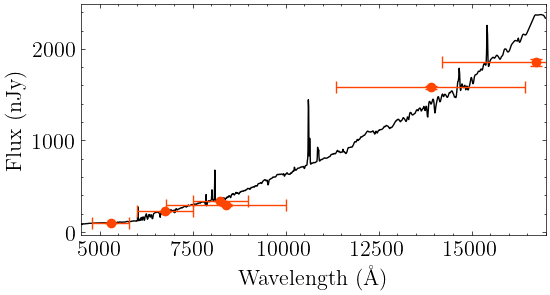

In [421]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [422]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [423]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-16.92, 0.86, 9.1)

## z=0.6178

In [424]:
redshift = 0.6178
ebv = 0.0404

In [425]:
MUSE_mags = np.array([23.852, 23.0267, 22.789])
dMUSE_mags = np.array([0.001, 0.0006, 0.001])

HST_mags = np.array([22.839,22.519,22.357])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [426]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [427]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w


In [428]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

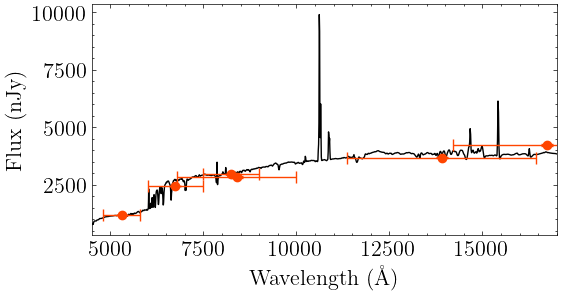

In [429]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [430]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [431]:
np.round(Mstar_KC,1)

9.2

In [432]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [433]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-19.76, -19.48, 9.5)

### Q24

In [434]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[4500,3543,4770]])

In [435]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
wfpc2_f814w


In [436]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

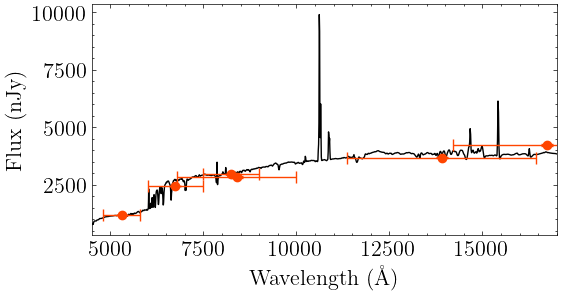

In [437]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [438]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [439]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-19.45, 0.74, 9.7)

## z=0.6183

In [440]:
redshift = 0.6183
ebv = 0.0404

In [441]:
MUSE_mags = np.array([24.419, 23.835, 23.141])
dMUSE_mags = np.array([0.002, 0.001, 0.002])

HST_mags = np.array([23.222, 22.613, 22.531])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [442]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [443]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w


In [444]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

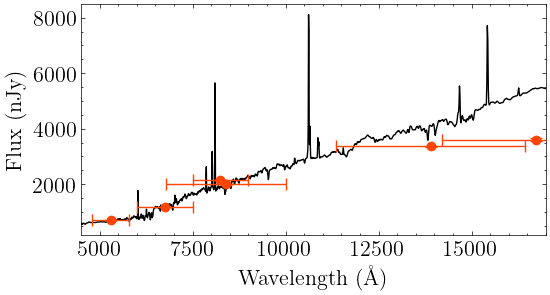

In [445]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [446]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [447]:
np.round(Mstar_KC,1)

9.9

In [448]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [449]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-19.6, -19.04, 9.8)

### Q24

In [450]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[4500,3543,4770]])

In [451]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
wfpc2_f814w


In [452]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

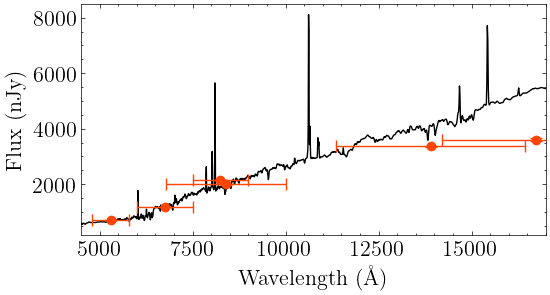

In [453]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [454]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [455]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-18.71, 0.91, 9.8)

## z=0.6469

In [456]:
redshift = 0.6469
ebv = 0.0397

In [457]:
MUSE_mags = np.array([26.6, 25.624, 25.11])
dMUSE_mags = np.array([0.01, 0.006, 0.01])

HST_mags = np.array([25.688, 23.091, 22.944])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [458]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [459]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w


In [460]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

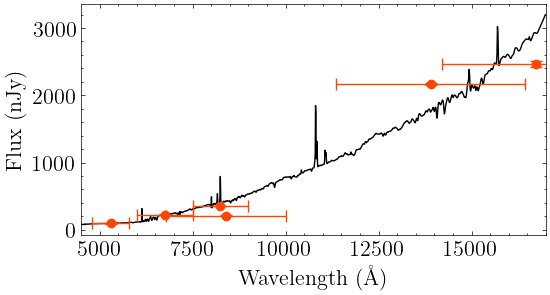

In [461]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [462]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [463]:
np.round(Mstar_KC,1)

9.5

In [464]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [465]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-18.11, -16.69, 8.9)

### Q24

In [466]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[4500,3543,4770]])

In [467]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
wfpc2_f814w


In [468]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

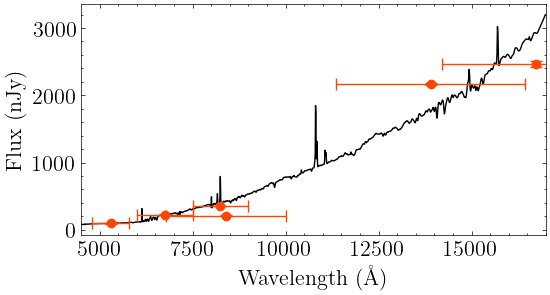

In [469]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [470]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [471]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-17.14, 0.56, 8.5)

## z=0.6478

In [472]:
redshift = 0.6478
ebv = 0.0404

In [473]:
MUSE_mags = np.array([26.69, 25.71,25.42])
dMUSE_mags = np.array([0.01, 0.01, 0.01])

HST_mags = np.array([25.258, 23.13, 22.991])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [474]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [475]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w


In [476]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

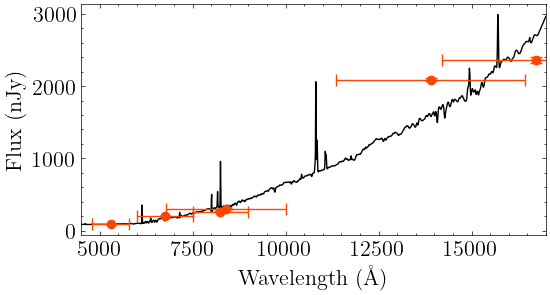

In [477]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [478]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [479]:
np.round(Mstar_KC,1)

9.4

In [480]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [481]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-17.87, -17.12, 9.3)

### Q24

In [482]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [483]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
wfpc2_f814w


In [484]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

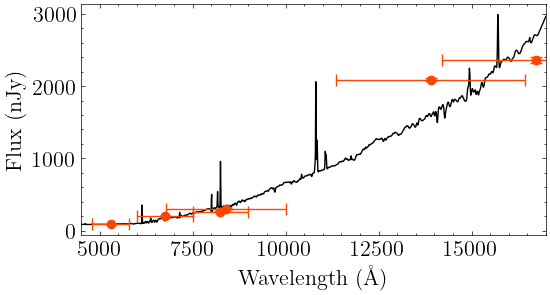

In [485]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [486]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [487]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-17.06, 1.12, 9.4)

## z=0.6518

In [488]:
redshift = 0.6518
ebv = 0.0404

In [489]:
HST_mags = np.array([22.175,21.234,21.109])
dHST_mags = compute_phot_err(HST_mags)

mags = HST_mags
dmags = dHST_mags

mags -= ebv*ext_scale[3:]

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [490]:
responses_lams = np.array([8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [491]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfpc2_f814w
wfpc2_f814w


In [492]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfpc2_f814w', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

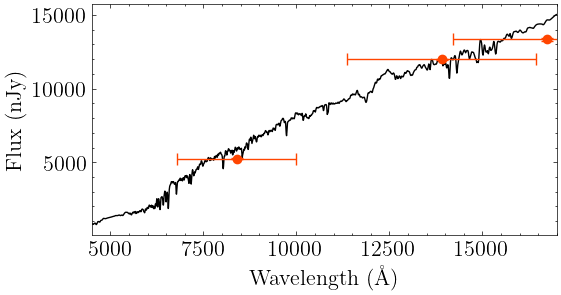

In [493]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen[3:], 1e9*3631*maggies, 
            xerr=dwavs_pass[3:], yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [494]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [495]:
np.round(Mstar_KC,1)

10.3

In [496]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [497]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-20.78, -20.25, 10.3)

### Q24

In [498]:
responses_lams = np.array([8140,14000,16000])
responses_out_lams = np.array([[4500,3543,4770]])

In [499]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfpc2_f814w
wfpc2_f814w
wfpc2_f814w


In [500]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['wfpc2_f814w', 'wfpc2_f814w', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

In [501]:
HST_mags = np.array([22.232,21.234,21.109])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((np.array([22.17]),HST_mags))
dmags =  np.concatenate((np.array([0.02]), dHST_mags))

mags -= ebv*ext_scale[2:]

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

(4500.0, 17000.0)

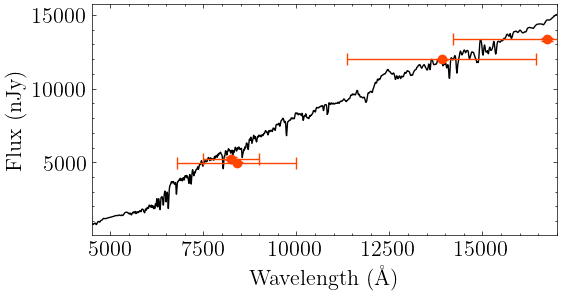

In [502]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen[2:], 1e9*3631*maggies, 
            xerr=dwavs_pass[2:], yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [503]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [504]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-20.05, 1.1, 10.4)

## z=0.6531

In [505]:
redshift = 0.6531
ebv = 0.0397

In [506]:
MUSE_mags = np.array([25.162, 24.289, 24.048])
dMUSE_mags = np.array([0.004, 0.002, 0.004])

HST_mags = np.array([24.187, 22.697, 22.483])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [507]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [508]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w


In [509]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

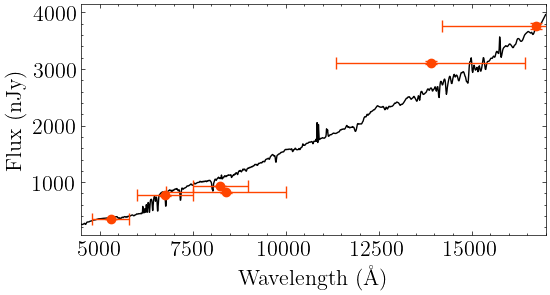

In [510]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [511]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [512]:
np.round(Mstar_KC,1)

9.5

In [513]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [514]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-18.87, -18.25, 9.6)

### Q24

In [515]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[4500,3543,4770]])

In [516]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_r
muse_pseudo_g
wfpc2_f814w


In [517]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_r', 'muse_pseudo_g', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

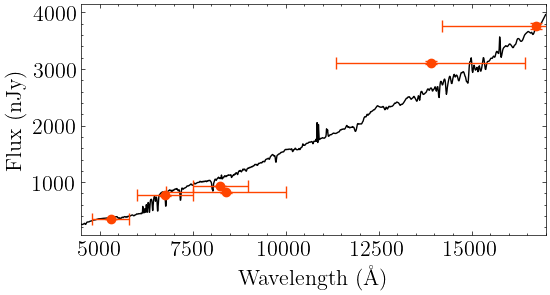

In [518]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [519]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [520]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-18.41, 0.68, 9.2)

## z=0.6780

In [521]:
redshift = 0.6780
ebv = 0.0404

In [522]:
MUSE_mags = np.array([25.629, 24.152, 23.813])
dMUSE_mags = np.array([0.008, 0.002, 0.005])

HST_mags = np.array([23.634,22.512,22.415])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [523]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [524]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w


In [525]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

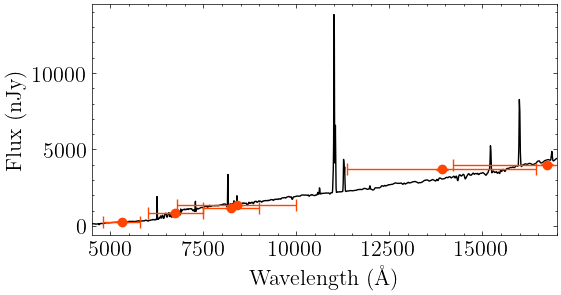

In [526]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [527]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [528]:
np.round(Mstar_KC,1)

9.6

In [529]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [530]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-19.25, -18.92, 9.4)

### Q24

In [531]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [532]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfpc2_f814w
muse_pseudo_g
wfpc2_f814w


In [533]:
dresp_lams

array([[ 2251.   ,   801.   ,   699.   ,   589.   ,  6449.   ,  8449.   ],
       [  645.154,   804.846,  2304.846,  2194.846,  8054.846, 10054.846],
       [ 2704.06 ,  1254.06 ,   245.94 ,   135.94 ,  5995.94 ,  7995.94 ]])

In [534]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['wfpc2_f814w', 'muse_pseudo_g', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

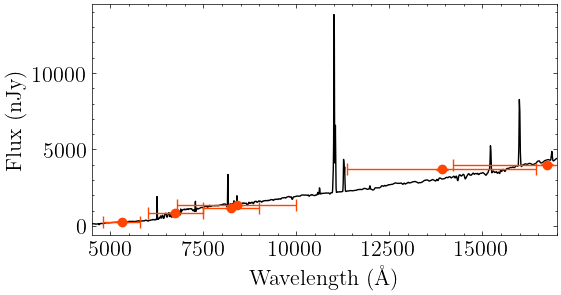

In [535]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [536]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [537]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-18.75, 1.41, 10.2)

## z=0.7010

In [538]:
redshift = 0.7010
ebv = 0.0397

In [539]:
MUSE_mags = np.array([24.894, 23.984, 23.326])
dMUSE_mags = np.array([0.003, 0.001, 0.002])

HST_mags = np.array([23.335, 21.244, 21.078])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [540]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [541]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w


In [542]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

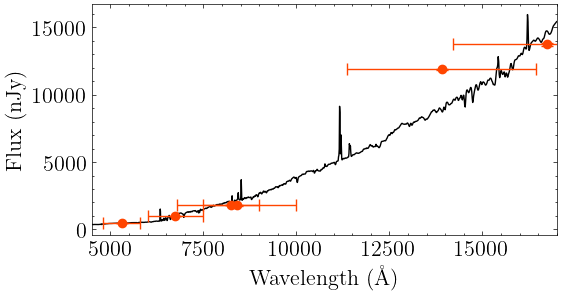

In [543]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [544]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [545]:
np.round(Mstar_KC,1)

10.3

In [546]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [547]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-20.18, -19.33, 10.2)

### Q24

In [555]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [549]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfpc2_f814w
muse_pseudo_r
wfpc2_f814w


In [550]:
dresp_lams

array([[2354.5  ,  904.5  ,  595.5  ,  485.5  , 6345.5  , 8345.5  ],
       [ 726.643,  723.357, 2223.357, 2113.357, 7973.357, 9973.357],
       [2813.77 , 1363.77 ,  136.23 ,   26.23 , 5886.23 , 7886.23 ]])

In [551]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['wfpc2_f814w', 'muse_pseudo_r', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

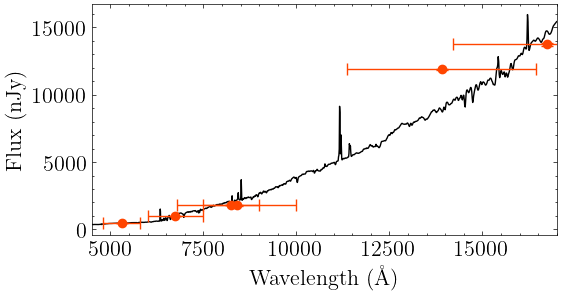

In [552]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [553]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [554]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-19.07, 1.17, 10.1)

## z=0.7293

In [556]:
redshift = 0.7293
ebv = 0.0397

In [557]:
MUSE_mags = np.array([23.75, 22.8725, 22.4264])
dMUSE_mags = np.array([0.001, 0.0005, 0.0008])

HST_mags = np.array([22.33, 21.577, 21.419])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [558]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [559]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_i


In [560]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

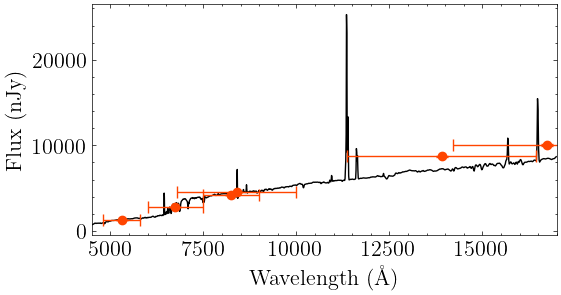

In [561]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [562]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [563]:
np.round(Mstar_KC,1)

9.9

In [564]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [565]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-20.66, -20.28, 10.0)

### Q24

In [566]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [567]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfpc2_f814w
muse_pseudo_r
muse_pseudo_i


In [568]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['wfpc2_f814w', 'muse_pseudo_r', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

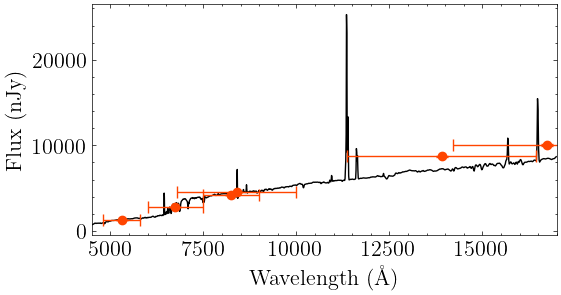

In [569]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [570]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [572]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-20.31, 0.86, 10.3)

## z=0.8217

In [573]:
redshift = 0.8217
ebv = 0.0404

In [574]:
MUSE_mags = np.array([25.051, 24.085, 23.297])
dMUSE_mags = np.array([0.005, 0.002, 0.003])

HST_mags = np.array([23.215, 22.064, 21.953])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [575]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [576]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfcam_JH
muse_pseudo_i


In [577]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfcam_JH', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

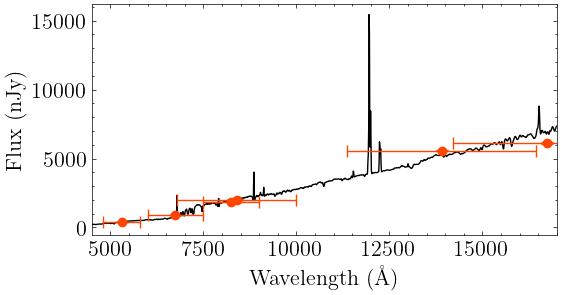

In [578]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [579]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [580]:
np.round(Mstar_KC,1)

10.1

In [581]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [582]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-20.53, -19.78, 10.4)

### Q24

In [583]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [584]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r
muse_pseudo_i


In [585]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

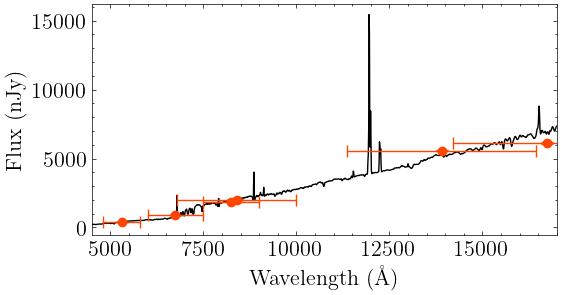

In [586]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [587]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [588]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-19.61, 1.1, 10.3)

## z=0.8404

In [589]:
redshift = 0.8404
ebv = 0.0404

In [590]:
HST_mags = np.array([23.367, 21.864, 21.706])
dHST_mags = compute_phot_err(HST_mags)

mags = HST_mags
dmags = dHST_mags

mags -= ebv*ext_scale[3:]

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [591]:
responses_lams = np.array([8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [592]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfcam_JH
wfpc2_f814w


In [593]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfcam_JH', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

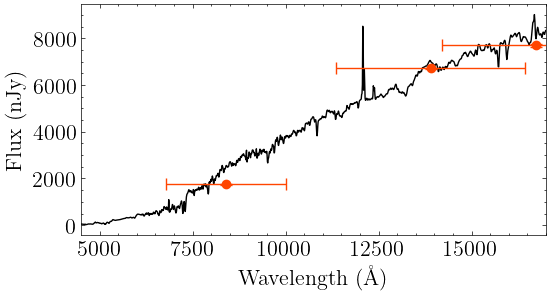

In [594]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen[3:], 1e9*3631*maggies, 
            xerr=dwavs_pass[3:], yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [595]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [596]:
np.round(Mstar_KC,1)

10.4

In [597]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [598]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-20.81, -20.05, 10.5)

### Q24

In [599]:
responses_lams = np.array([8140,14000,16000])
responses_out_lams = np.array([[4500,3543,4770]])

In [600]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfpc2_f814w
wfpc2_f814w
wfpc2_f814w


In [601]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['wfpc2_f814w', 'wfpc2_f814w', 'wfpc2_f814w']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

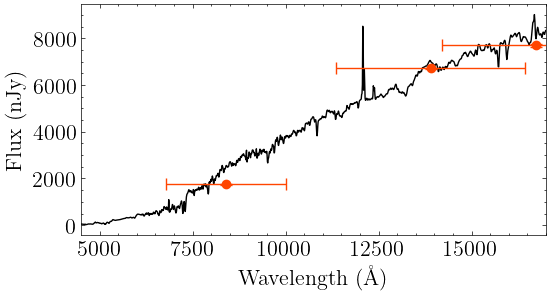

In [602]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen[3:], 1e9*3631*maggies, 
            xerr=dwavs_pass[3:], yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [603]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [604]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-19.76, 1.6, 10.7)

## z=0.8458

In [605]:
redshift = 0.8458
ebv = 0.0404

In [606]:
MUSE_mags = np.array([24.367, 23.229, 22.311])
dMUSE_mags = np.array([0.002, 0.001, 0.001])

HST_mags = np.array([22.388, 21.283, 21.115])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [607]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [608]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfcam_JH
muse_pseudo_i


In [609]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i', 'wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfcam_JH', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

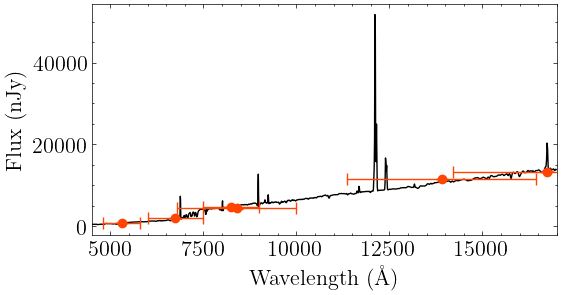

In [610]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [611]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [612]:
np.round(Mstar_KC,1)

10.4

In [613]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [614]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-21.47, -20.85, 10.6)

### Q24

In [615]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [616]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r
muse_pseudo_i


In [617]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

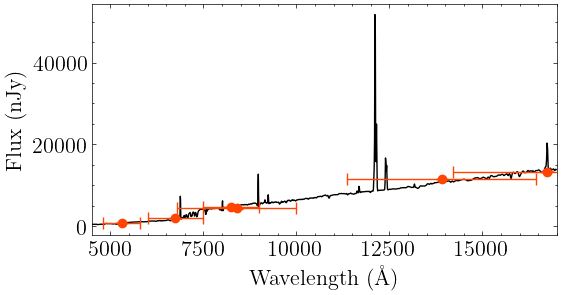

In [618]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [619]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [620]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-20.68, 1.21, 10.7)

## z=0.9576

In [621]:
redshift = 0.9576
ebv = 0.0404

In [622]:
MUSE_mags = np.array([24.338, 23.442, 22.511])
dMUSE_mags = np.array([0.003, 0.001, 0.001])

HST_mags = np.array([22.363, 21.06, 20.925])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [623]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [624]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfcam_JH
muse_pseudo_i


In [625]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfcam_JH', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

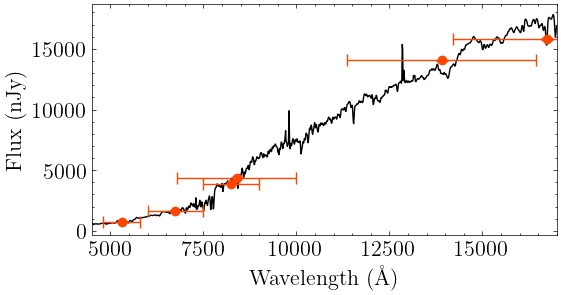

In [626]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [627]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [628]:
np.round(Mstar_KC,1)

10.9

In [629]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [630]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-22.0, -21.3, 10.9)

### Q24

In [631]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [632]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r
muse_pseudo_i


In [633]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

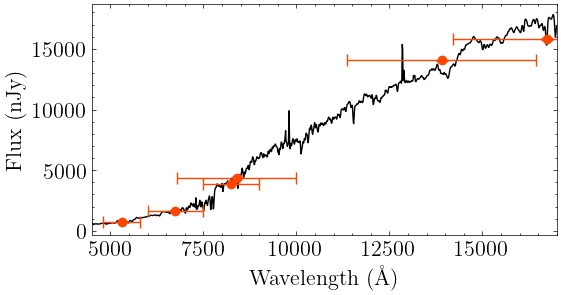

In [634]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [635]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [636]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-21.03, 1.29, 10.9)

## z=1.0959

In [637]:
redshift = 1.0959
ebv = 0.0397

In [638]:
MUSE_mags = np.array([26.44, 26.23, 25.76])
dMUSE_mags = np.array([0.01, 0.01, 0.02])

HST_mags = np.array([25.533,23.742,23.388])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [639]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [640]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfcam_JH
muse_pseudo_i


In [641]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfcam_JH', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

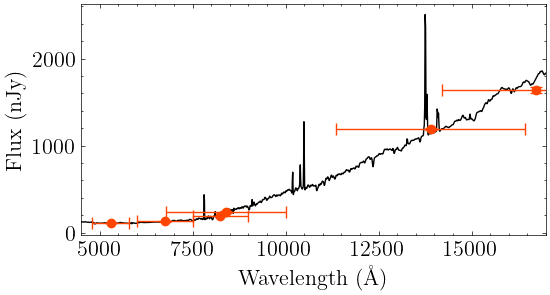

In [642]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [643]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [644]:
np.round(Mstar_KC,1)

10.0

In [645]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [646]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-19.64, -18.65, 10.0)

### Q24

In [647]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [648]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r
muse_pseudo_i


In [649]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

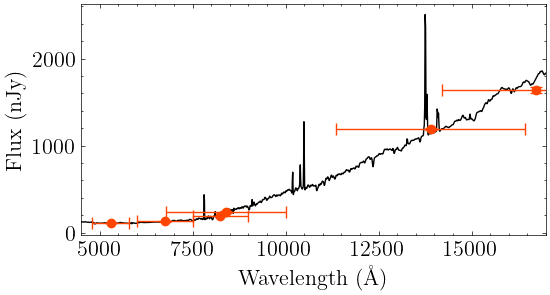

In [650]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [651]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [652]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-18.37, 1.05, 9.8)

## z=1.1932

In [653]:
redshift = 1.1932
ebv = 0.0397

In [654]:
MUSE_mags = np.array([27.31, 26.62, 26.02])
dMUSE_mags = np.array([0.03, 0.01, 0.02])

HST_mags = np.array([25.776, 23.678, 23.51])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [655]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [656]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfcam_JH
muse_pseudo_i


In [657]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfcam_JH', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

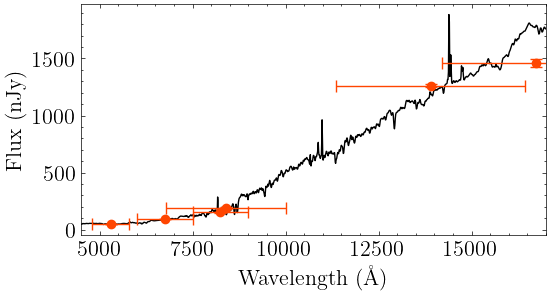

In [658]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [659]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [660]:
np.round(Mstar_KC,1)

10.1

In [661]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [662]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-20.02, -19.0, 10.1)

### Q24

In [663]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [664]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w
muse_pseudo_i


In [665]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

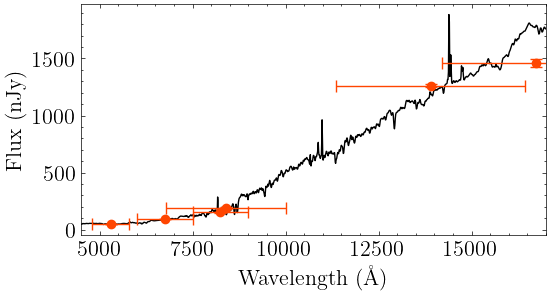

In [666]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [667]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [668]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-18.69, 1.15, 10.0)

## z=1.1935

In [669]:
redshift = 1.1935
ebv = 0.0397

In [670]:
MUSE_mags = np.array([24.704, 24.261, 23.799])
dMUSE_mags = np.array([0.002, 0.002, 0.003])

HST_mags = np.array([23.519, 22.328, 22.202])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [671]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [672]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfcam_JH
muse_pseudo_i


In [673]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfcam_JH', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

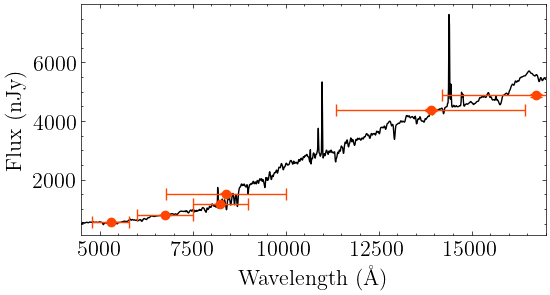

In [674]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [675]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [676]:
np.round(Mstar_KC,1)

10.6

In [677]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [678]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-21.4, -20.81, 10.6)

### Q24

In [679]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [680]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w
muse_pseudo_i


In [681]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

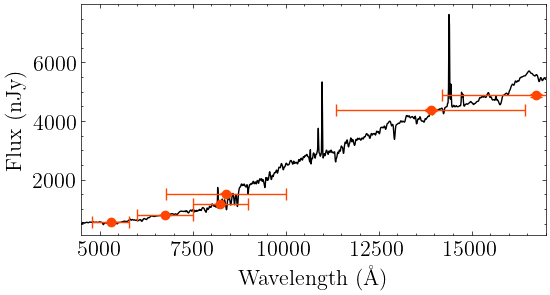

In [682]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [683]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [684]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-20.61, 0.65, 9.9)

## z=1.2256

In [701]:
redshift = 1.2256
ebv = 0.0397

In [702]:
MUSE_mags = np.array([25.879, 25.234, 24.655])
dMUSE_mags = np.array([0.007, 0.004, 0.006])

HST_mags = np.array([24.765, 23.365, 23.254])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [703]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [704]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfcam_JH
muse_pseudo_i


In [705]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfcam_JH', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

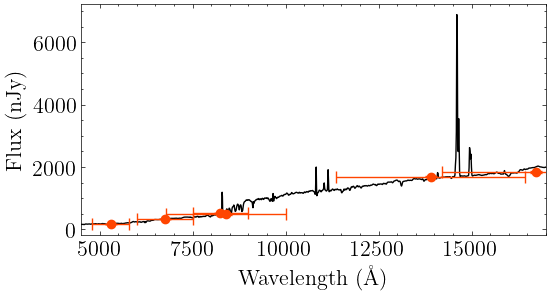

In [706]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [707]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [708]:
np.round(Mstar_KC,1)

10.0

In [709]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [710]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-20.46, -20.03, 10.0)

### Q24

In [711]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [712]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w
muse_pseudo_i


In [713]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

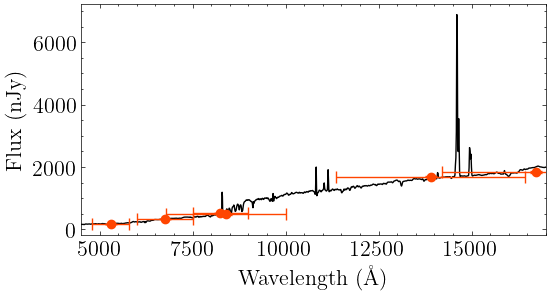

In [714]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [715]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [716]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-19.88, 1.03, 10.3)

## z=1.2787

In [717]:
redshift = 1.2787
ebv = 0.0404

In [718]:
MUSE_mags = np.array([26.45, 25.299, 24.26])
dMUSE_mags = np.array([0.01, 0.005, 0.005])

HST_mags = np.array([24.031,22.043,22.006])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [719]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [720]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfcam_JH
muse_pseudo_i


In [721]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfcam_JH', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

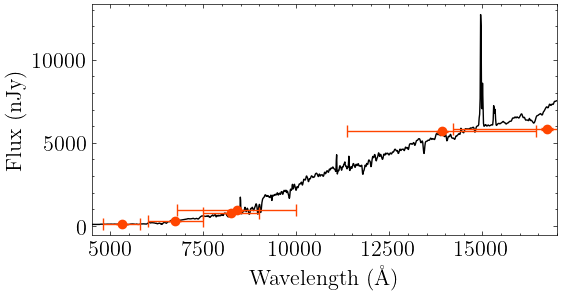

In [722]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [723]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [724]:
np.round(Mstar_KC,1)

10.8

In [725]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [726]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-21.89, -21.15, 10.9)

### Q24

In [727]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [728]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
wfpc2_f814w
muse_pseudo_i


In [729]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'wfpc2_f814w', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

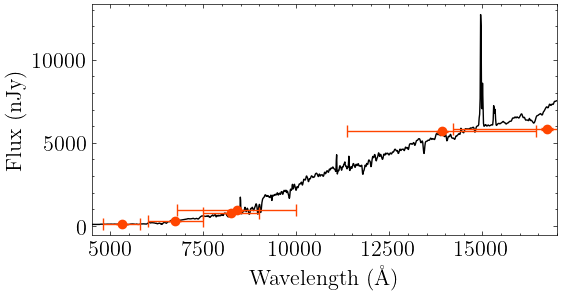

In [730]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [731]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [732]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-20.88, 1.24, 10.8)

## z=1.2988

In [733]:
redshift = 1.2988
ebv = 0.0404

In [734]:
# Make global dictionaries
PHOTFNU_dict_IR = {'F140W':PHOTFNU_F140W, 'F160W':PHOTFNU_F160W}
t_exp_dict_IR = {'F140W':t_exp_F140W, 'F160W':t_exp_F160W}

In [735]:
def compute_phot_err_IR(mags):
    
    '''
    mags: list of AB magnitudes
    '''
    
    F_nu_Jy_arr = 3631*10**(-0.4*mags) # In Jy
    
    dmags = np.zeros(len(mags))

    for i in range(len(PHOTFNU_dict_IR)):
        
        filt = list(PHOTFNU_dict_IR.keys())[i]
        F_nu_Jy = F_nu_Jy_arr[i]

        count_rate = F_nu_Jy/PHOTFNU_dict_IR[filt] # Divide by sensitivity
        counts = count_rate*t_exp_dict_IR[filt] # Get counts

        counts_err = np.sqrt(counts) # Get count error assuming Poisson counting
        count_rate_err = counts_err/t_exp_dict_IR[filt] # Divide counts by exposure time
        dF_nu_Jy = count_rate_err*PHOTFNU_dict_IR[filt] # Get error in F_nu

        # Compute error in magnitude using propagation of error
        dmags[i] = np.abs((-2.5/np.log(10))*(dF_nu_Jy/F_nu_Jy))    
    
    return np.round(dmags,3)

In [736]:
HST_mags = np.array([22.141,21.962])
dHST_mags = compute_phot_err_IR(HST_mags)

mags = HST_mags
dmags = dHST_mags

mags -= ebv*ext_scale[4:]

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [737]:
responses_lams = np.array([14000,16000])
responses_out_lams = np.array([[6231,4770]])

In [738]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfcam_JH
wfcam_JH


In [739]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfcam_JH', 'wfcam_JH']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

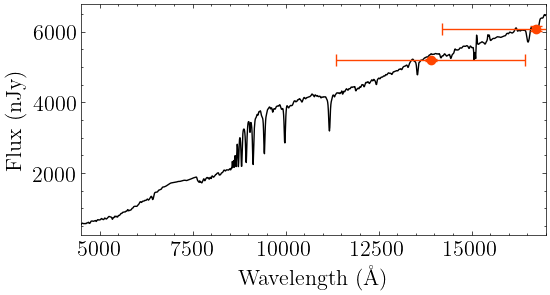

In [740]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen[4:], 1e9*3631*maggies, 
            xerr=dwavs_pass[4:], yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [741]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [742]:
np.round(Mstar_KC,1)

10.3

In [743]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [744]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-21.81, -21.52, 10.3)

### Q24

In [745]:
responses_lams = np.array([14000,16000])
responses_out_lams = np.array([[4500,3543,4770]])

In [746]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfcam_JH
wfcam_JH
wfcam_JH


In [747]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['wfcam_JH', 'wfcam_JH', 'wfcam_JH']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

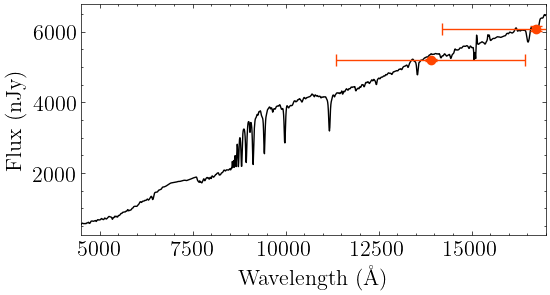

In [748]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen[4:], 1e9*3631*maggies, 
            xerr=dwavs_pass[4:], yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [749]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [750]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-21.43, 0.73, 10.4)

## z=1.0448?

In [55]:
redshift = 1.0448
ebv = 0.0397

In [56]:
MUSE_mags = np.array([27.69, 25.133, 23.738])
dMUSE_mags = np.array([0.04, 0.004, 0.003])

HST_mags = np.array([23.913, 22.271, 22.012])
dHST_mags = compute_phot_err(HST_mags)

mags = np.concatenate((MUSE_mags,HST_mags))
dmags = np.concatenate((dMUSE_mags,dHST_mags))

mags -= ebv*ext_scale

maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

### J15

In [57]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[6231,4770]])

In [58]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

wfcam_JH
muse_pseudo_i


In [59]:
responses_out = ['sdss_r0', 'sdss_g0']
responses_map = ['wfcam_JH', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

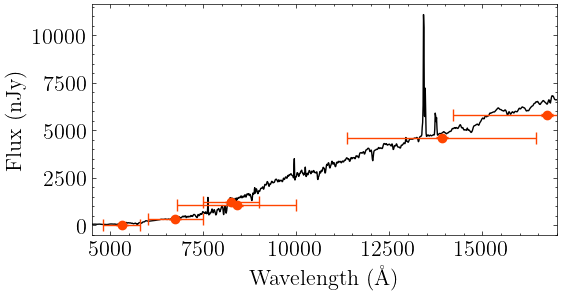

In [60]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [61]:
derived = kc.derived(redshift=redshift, coeffs=coeffs)
Mstar_KC = np.log10(derived['mremain'])

In [62]:
np.round(Mstar_KC,1)

10.5

In [63]:
Mr = absmag[0]
Mg = absmag[1]
Mstar = get_Mstar_15(Mr, Mg)

In [64]:
np.round(Mr,2), np.round(Mg,2), np.round(Mstar,1)

(-21.05, -20.55, 10.3)

### Q24

In [65]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [66]:
dresp_lams = np.abs(responses_out_lams.T*(1+redshift)-responses_lams)
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']

for i in range(dresp_lams.shape[0]):
    print(responses[np.argmin(dresp_lams[i,:])])

muse_pseudo_i
muse_pseudo_r
muse_pseudo_i


In [67]:
responses_out = ['bessell_B', 'sdss_u0', 'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

(4500.0, 17000.0)

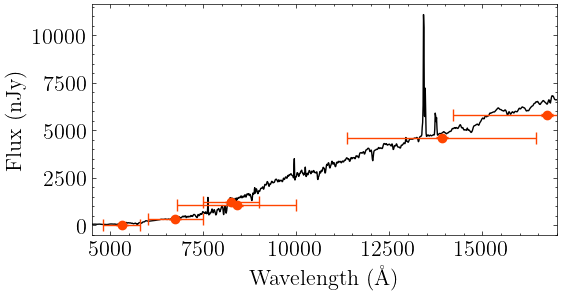

In [68]:
fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift))
spec = np.array(coeffs.dot(kc.templates.restframe_flux) / (1. + redshift))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies, 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)

In [69]:
MB = absmag[0]
ug = absmag[1]-absmag[2]
Mstar = get_Mstar_24(MB, ug)

In [70]:
np.round(MB,2), np.round(ug,2), np.round(Mstar,1)

(-20.28, 1.76, 11.0)

# DRAFT

In [ ]:
def compute_phot_err(mag, filt):
    
    '''
    mags: list of AB magnitudes
    '''
    
    F_nu_Jy = 3631*10**(-0.4*mag) # In Jy

    count_rate = F_nu_Jy/PHOTFNU_dict[filt] # Divide by sensitivity
    counts = count_rate*t_exp_dict[filt] # Get counts

    counts_err = np.sqrt(counts) # Get count error assuming Poisson counting
    count_rate_err = counts_err/t_exp_dict[filt] # Divide counts by exposure time
    dF_nu_Jy = count_rate_err*PHOTFNU_dict[filt] # Get error in F_nu

    # Compute error in magnitude using propagation of error
    dmag = np.abs((-2.5/np.log(10))*(dF_nu_Jy/F_nu_Jy))    

    return np.round(dmag,3)

In [ ]:
pg_mags = np.array([25.683,26.415,25.945,26.446])
#pg_mags -= np.array([0.131,0.129,0.129,0.131])
dpg_mags = np.array([0.006,0.011,0.008,0.012])

pr_mags = np.array([24.147,26.204,25.405,25.299])
#pr_mags -= np.array([0.099,0.097,0.097,0.099])
dpr_mags = np.array([0.002,0.010,0.005,0.005])

pi_mags = np.array([23.800,25.714,24.852,24.260])
#pi_mags -= np.array([0.071,0.070,0.070,0.071])
dpi_mags = np.array([0.003,0.017,0.008,0.005])

In [ ]:
pg_mags[0], dpg_mags[0]

In [ ]:
pr_mags[0], dpr_mags[0]

In [ ]:
pi_mags[0], dpi_mags[0]

In [ ]:
F814W_mags = np.array([23.634,25.533,24.765,24.031])
#F814W_mags -= np.array([0.070,0.069,0.069,0.070])
dF814W_mags = [compute_phot_err(mag,'F814W') for mag in F814W_mags]

F140W_mags = np.array([22.137,23.341,22.894,22.134])
#F140W_mags -= np.array([0.030,0.030,0.030,0.030])
dF140W_mags = [compute_phot_err(mag,'F140W') for mag in F140W_mags]

F160W_mags = np.array([21.989,23.178,22.693,22.049])
#F160W_mags -= np.array([0.022,0.022,0.022,0.022])
dF160W_mags = [compute_phot_err(mag,'F160W') for mag in F160W_mags]

In [ ]:
dF140W_mags, dF160W_mags, dF814W_mags

In [ ]:
redshift = np.array([0.6780, 1.0959, 1.2256, 1.2787])

mags = np.zeros((4,6))
dmags = np.zeros((4,6))

mags[:,0] = pg_mags
dmags[:,0] = dpg_mags

mags[:,1] = pr_mags
dmags[:,1] = dpr_mags

mags[:,2] = pi_mags
dmags[:,2] = dpi_mags

mags[:,3] = F814W_mags
dmags[:,3] = dF814W_mags

mags[:,4] = F140W_mags
dmags[:,4] = dF140W_mags

mags[:,5] = F160W_mags
dmags[:,5] = dF160W_mags

In [ ]:
mags

In [ ]:
#dmags = 0.6*np.ones((4,3))

In [ ]:
dmags

In [ ]:
df = pd.DataFrame()

In [ ]:
df['z'] = redshift

In [ ]:
df['pseudo-g'] = pg_mags
df['pseudo-r'] = pr_mags
df['pseudo-i'] = pi_mags
df['F814W'] = F814W_mags
df['F140W'] = F140W_mags
df['F160W'] = F160W_mags


In [ ]:
df

# Bandpass filter wavelengths

In [ ]:
#wavs_pass_min = np.array([11370.0,14210.0,6800.0,4800,6000,7500])
#wavs_pass_max = np.array([16450.0,19240.0,10000.0,5800,7500,9000])

wavs_pass_min = np.array([4800,6000,7500,6800,11370,14210])
wavs_pass_max = np.array([5800,7500,9000,10000,16450,19240])

wavs_pass_cen = .5*(wavs_pass_max+wavs_pass_min)
dwavs_pass = .5*(wavs_pass_max-wavs_pass_min)

In [ ]:
wavs_pass_cen

# Fit

In [ ]:
def get_maggies(m):
    # Maggies
    mu = 10**(-0.4*m)
    return mu

In [ ]:
def get_ivar_maggies(mu, dm):
    dmu = np.abs(-0.4*np.log(10)*dm*mu)
    # Inverse variance for maggies
    return dmu**-2

In [ ]:
maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

In [ ]:
maggies

In [ ]:
ivar

In [ ]:
responses_lams = np.array([5300,6750,8250,8140,14000,16000,])
responses_out_lams = np.array([[4500,3543,4770]])

In [ ]:
responses_out_lams*(1+1)

In [ ]:
np.abs(responses_out_lams.T*(1+1)-responses_lams)

In [ ]:
responses = ['muse_pseudo_g', 'muse_pseudo_r', 'muse_pseudo_i','wfpc2_f814w','wfcam_JH','wfcam_H']
responses_out = ['bessell_B', 'sdss_u0',  'sdss_g0']
responses_map = ['muse_pseudo_i', 'muse_pseudo_r', 'muse_pseudo_i']

kc = kcorrect.kcorrect.Kcorrect(responses=responses, responses_out=responses_out, responses_map=responses_map,
                               cosmo=cosmo)

# "coeffs" is a [4,6]-array coefficients multiplying each template
coeffs = kc.fit_coeffs(redshift=redshift, maggies=maggies, ivar=ivar)

# "k" is a [3]-array with the K-corrections in magnitude units,
# from iri to Bug
k = kc.kcorrect(redshift=redshift, coeffs=coeffs)

# "absmag" is also a [3]-array resuling from applying K-corrections
# and the distance modulus
absmag = kc.absmag(redshift=redshift, maggies=maggies, ivar=ivar, coeffs=coeffs)

# Stellar mass estimates

In [ ]:
MB = absmag[:,0]
ug = absmag[:,1]-absmag[:,2]

In [ ]:
np.round(MB,2), np.round(ug,2)

In [ ]:
def get_Mstar(MB, ug):
    
    logM_star_blue = -0.36*MB + 2.17*ug + 1.1
    logM_star_red = -0.36*MB + 0.72*ug + 2.4
    
    idx = ug>=0.9
    
    logM_star = logM_star_blue.copy()
    
    logM_star[idx] = logM_star_red[idx]
    
    return logM_star

In [ ]:
np.round(get_Mstar(MB, ug), 1)

# Assess fit

In [ ]:
n = 0

fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift[n]))
spec = np.array(coeffs.dot(kc.templates.restframe_flux)[n,:] / (1. + redshift[n]))

idx = (wave>=4500)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies[n,:], 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar[n,:]**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,17000)
ax.set_title(r'$z_\mathrm{gal}=0.6780, \ \log M_*/M_\odot = 7.9$', fontsize=14)

In [ ]:
n = 1

fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift[n]))
spec = np.array(coeffs.dot(kc.templates.restframe_flux)[n,:] / (1. + redshift[n]))

idx = (wave>=4800)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies[n,:], 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar[n,:]**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4800,17000)
ax.set_title(r'$z_\mathrm{gal}=1.0959, \ \log M_*/M_\odot = 8.1$', fontsize=14)

In [ ]:
n = 2

fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift[n]))
spec = np.array(coeffs.dot(kc.templates.restframe_flux)[n,:] / (1. + redshift[n]))

idx = (wave>=4800)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies[n,:], 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar[n,:]**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4800,17000)
ax.set_title(r'$z_\mathrm{gal}=1.2256, \ \log M_*/M_\odot = 8.5$', fontsize=14)

In [ ]:
n = 3

fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift[n]))
spec = np.array(coeffs.dot(kc.templates.restframe_flux)[n,:] / (1. + redshift[n]))

idx = (wave>=4800)&(wave<=17000)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen, 1e9*3631*maggies[n,:], 
            xerr=dwavs_pass, yerr=1e9*3631*np.sqrt(ivar[n,:]**-1),
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4800,17000)
ax.set_title(r'$z_\mathrm{gal}=1.2787, \ \log M_*/M_\odot = 8.7$', fontsize=14)

# Select galaxies

In [ ]:
redshift = np.array([#0.6780, 
                     #1.0959, 
                     #1.2256, 
                     1.2787,
                    ])

        # pseudo-g psuedo-r pseudo-i F814W F140W F160W
mags = np.array([
       #[25.8905696, 24.673364 , 24.4225636], #23.5323008, 20.6465592, 20.7507296], # z=0.67
       #[26.2763076, 26.100659 , 25.6345591,], #25.4552748, 22.5160102, 22.7950176], # z=1.09
       #[25.8070028, 25.302177 , 24.7729573,],# 24.6876644, 21.5651906, 21.5981328], # z=1.22
       [26.3055696, 25.194364 , 24.1795636,], #23.9523008, 20.7265592, 20.9007296], # z=1.27
        ])

dmags = np.array([
       #[0.008, 0.003, 0.006]#, 0.015, 0.003, 0.007],
       #[0.011, 0.01 , 0.017,],# 0.037, 0.008, 0.017],
       #[0.008, 0.005, 0.008,],# 0.026, 0.005, 0.010],
       [0.012, 0.005, 0.005,], # 0.019, 0.003, 0.007],
        ])

In [ ]:
mags = np.zeros((4,6))
dmags = np.zeros((4,6))

mags[:,0] = pg_mags
dmags[:,0] = dpg_mags

mags[:,1] = pr_mags
dmags[:,1] = dpr_mags

mags[:,2] = pi_mags
dmags[:,2] = dpi_mags

mags[:,3] = F814W_mags
dmags[:,3] = dF814W_mags

mags[:,4] = F140W_mags
dmags[:,4] = dF140W_mags

mags[:,5] = F160W_mags
dmags[:,5] = dF160W_mags

In [ ]:
maggies = get_maggies(mags)
ivar = get_ivar_maggies(maggies, dmags)

In [ ]:
#wavs_pass_min = np.array([11370.0,14210.0,6800.0,4800,6000,7500])
#wavs_pass_max = np.array([16450.0,19240.0,10000.0,5800,7500,9000])

wavs_pass_min = np.array([4800,6000,7500,6800,11370,14210])
wavs_pass_max = np.array([5800,7500,9000,10000,16450,19240])

wavs_pass_cen = .5*(wavs_pass_max+wavs_pass_min)
dwavs_pass = .5*(wavs_pass_max-wavs_pass_min)

In [ ]:
n = 0

fig, ax = plt.subplots(1, figsize=(6,3))

wave = np.array(kc.templates.restframe_wave * (1. + redshift[n]))
spec = np.array(coeffs.dot(kc.templates.restframe_flux)[n,:] / (1. + redshift[n]))

idx = (wave>=4500)&(wave<=9300)

wave_slice = wave[idx]
spec_slice = spec[idx]

ax.plot(wave_slice,1e9*3.34*10**4*wave_slice**2*spec_slice)
ax.errorbar(wavs_pass_cen[0:3], 1e9*3631*maggies[n,:][0:3], 
            xerr=dwavs_pass[0:3], yerr=1e9*3631*np.sqrt(ivar[n,:]**-1)[0:3],
           linestyle='none', capsize=4, marker='o',
           color='orangered')

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux (nJy)')
ax.set_xlim(4500,9300)
ax.set_title(r'$z_\mathrm{gal}=1.2256$', fontsize=14)